In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [3]:
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [5]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [18]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

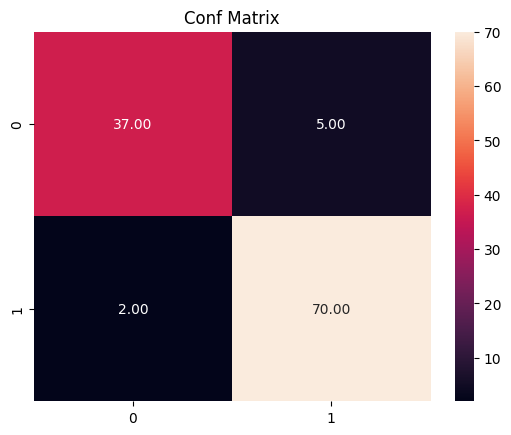

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='.2f')
plt.title('Conf Matrix')
plt.show()

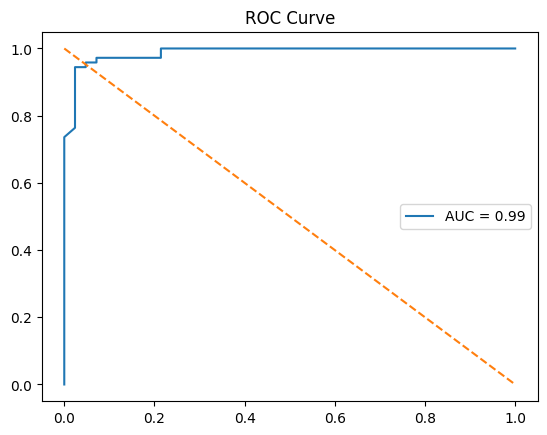

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob[:,1])
roc_auc = auc(fpr,tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[1,0],'--')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [21]:
imp = model.feature_importances_
feats = pd.Series(imp, index=x.columns).sort_values(ascending=False)

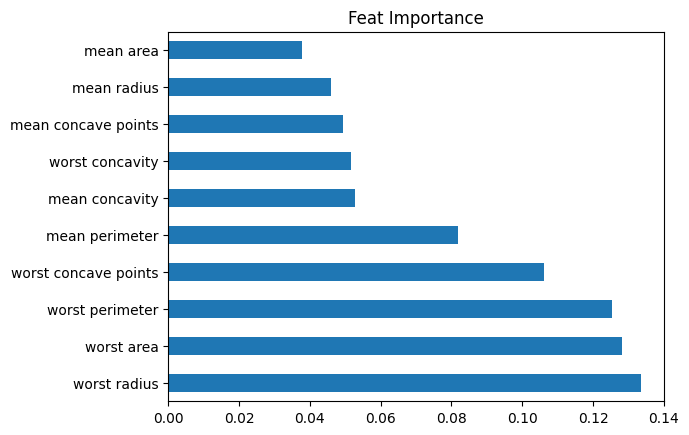

In [22]:
feats.head(10).plot(kind='barh')
plt.title('Feat Importance')
plt.show()